# Panglial Connexin Dynamics in MS Spinal Cord

This notebook profiles `GJC2` (Cx47), `GJB1` (Cx32), and `GJA1` (Cx43) in the spinal-cord atlas at `baloMS_indep_clust_balo_MANA_SC_annot.h5ad`.

Unlike the Jakel-style MS notebook, this dataset does not expose lesion-state or timepoint columns. The analysis therefore uses `leiden_0.5_names` as the main cell-type axis and `sample_id` to compare the two spinal-cord specimens.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next((path for path in CANDIDATES if (path / "src").exists() and (path / "config").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repository root. Start Jupyter from the repo root or notebooks directory.")

MPL_CACHE_DIR = REPO_ROOT / ".cache" / "matplotlib"
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))

if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from cx47_oligo.exports import ensure_results_dir, save_current_figure, save_json, save_table
from cx47_oligo.h5ad_tools import adata_overview, expression_frame, load_h5ad, obs_column_summary, resolve_gene_symbols
from cx47_oligo.scanpy_tools import grouped_gene_expression_stats

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#fbfcfd",
        "axes.edgecolor": "#d7dde2",
        "grid.color": "#dde4ea",
        "grid.alpha": 0.75,
    }
)


In [2]:
DEFAULT_DATASET_PATH = Path("/Users/chrislangseth/Downloads/baloMS_indep_clust_balo_MANA_SC_annot.h5ad")
DATA_ROOT = REPO_ROOT / "data" / "raw"
LOCAL_H5AD_FILES = sorted(DATA_ROOT.glob("*.h5ad"))

DATASET_PATH = DEFAULT_DATASET_PATH if DEFAULT_DATASET_PATH.exists() else (LOCAL_H5AD_FILES[0] if LOCAL_H5AD_FILES else None)
if DATASET_PATH is None or not DATASET_PATH.exists():
    raise FileNotFoundError("No spinal-cord .h5ad file was found. Set DATASET_PATH manually.")

RESULTS_DIR = ensure_results_dir(REPO_ROOT, "01_panglial_network_ms_spinalcord", DATASET_PATH)
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET_GENES = ["GJC2", "GJB1", "GJA1"]
CELLTYPE_COLUMN = "leiden_0.5_names"
SAMPLE_COLUMN = "sample_id"
PREFERRED_CELLTYPE_ORDER = [
    "Oligodendrocytes_2",
    "Oligodendrocytes_1",
    "Oligodendrocyte Precursor Cells",
    "Astrocytes",
    "Astrocytes Disease Associated",
    "Mixed Glia Disease Assocaited",
    "Myeloid",
    "Mixed immune",
    "Lymphoid",
    "Endothelial cells",
    "Perivascular (Fibroblast?)",
    "Schwann cells",
    "Ependymal cells",
    "Neurons",
]
GLIAL_PREFERRED_ORDER = [
    "Oligodendrocytes_2",
    "Oligodendrocytes_1",
    "Oligodendrocyte Precursor Cells",
    "Astrocytes",
    "Astrocytes Disease Associated",
    "Mixed Glia Disease Assocaited",
]
GLIAL_KEYWORDS = ["oligodendro", "astro", "glia"]

print("Dataset:", DATASET_PATH)
print("Results:", RESULTS_DIR)


Dataset: /Users/chrislangseth/Downloads/baloMS_indep_clust_balo_MANA_SC_annot.h5ad
Results: /Users/chrislangseth/work/karolinska_institutet/projects/cx47-oligo/results/01_panglial_network_ms_spinalcord/baloms_indep_clust_balo_mana_sc_annot


In [7]:
adata = load_h5ad(DATASET_PATH)
adata.obs_names_make_unique()
display(adata_overview(adata))

required_columns = [CELLTYPE_COLUMN, SAMPLE_COLUMN]
missing_columns = [column for column in required_columns if column not in adata.obs.columns]
if missing_columns:
    raise KeyError(f"Missing required obs columns: {missing_columns}")

metadata_columns = [
    column
    for column in [
        CELLTYPE_COLUMN,
        SAMPLE_COLUMN,
        "run",
        "segmentation_method",
        "n_genes_by_counts",
        "n_counts",
    ]
    if column in adata.obs.columns
]
metadata_summary = obs_column_summary(adata).loc[lambda df: df["column"].isin(metadata_columns)]
display(metadata_summary)
save_table(metadata_summary, RESULTS_DIR / "core_obs_summary.csv", index=False)

present_genes, missing_genes, gene_to_var = resolve_gene_symbols(adata, TARGET_GENES)
gene_status = pd.DataFrame(
    {
        "query_gene": TARGET_GENES,
        "resolved_var": [gene_to_var.get(gene, "") for gene in TARGET_GENES],
        "present_in_dataset": [gene in present_genes for gene in TARGET_GENES],
    }
)
display(gene_status)
save_table(gene_status, RESULTS_DIR / "target_gene_status.csv", index=False)

save_json(
    {
        "dataset_path": str(DATASET_PATH),
        "results_dir": str(RESULTS_DIR),
        "celltype_column": CELLTYPE_COLUMN,
        "sample_column": SAMPLE_COLUMN,
        "target_genes": TARGET_GENES,
        "present_genes": present_genes,
        "missing_genes": missing_genes,
    },
    RESULTS_DIR / "run_metadata.json",
)

if missing_genes:
    display(
        Markdown(
            "**Missing genes:** "
            + ", ".join(f"`{gene}`" for gene in missing_genes)
            + " are not present in this spinal-cord export."
        )
    )


/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


,metric,value
0,n_obs,202751
1,n_vars,5101
2,obs_columns,29
3,var_columns,9
4,layers,counts
5,obsm,"X_mana_gauss, X_pca, X_scVI, X_umap, spatial"
6,uns_keys,"X_mana_gauss_params, gmm_mana_10_colors, gmm_m..."
7,raw_present,False


,column,dtype,n_unique,null_fraction,examples
0,run,category,2,0.0,output-XETG00599__0076063__S07-256__20260115__...
1,sample_id,category,2,0.0,"S07-256, S13-019"
3,segmentation_method,category,3,0.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...
13,leiden_0.5_names,category,14,0.0,"Perivascular (Fibroblast?), Schwann cells, End..."
21,n_genes_by_counts,int32,1571,0.0,"682, 68, 348, 655"
23,n_counts,float32,3502,0.0,"1195.0, 78.0, 490.0, 1111.0"


,query_gene,resolved_var,present_in_dataset
0,GJC2,GJC2,True
1,GJB1,GJB1,True
2,GJA1,GJA1,True


In [8]:
def ordered_labels(observed_labels, preferred_labels=None):
    observed = [str(label) for label in observed_labels]
    if preferred_labels is None:
        return observed
    ordered = [label for label in preferred_labels if label in observed]
    remainder = [label for label in observed if label not in ordered]
    return ordered + remainder


def reorder_matrix(frame, row_order=None, col_order=None):
    working = frame.copy()
    if row_order is not None:
        rows = [row for row in row_order if row in working.index]
        extra_rows = [row for row in working.index if row not in rows]
        working = working.reindex(rows + extra_rows)
    if col_order is not None:
        cols = [col for col in col_order if col in working.columns]
        extra_cols = [col for col in working.columns if col not in cols]
        working = working.reindex(columns=cols + extra_cols)
    return working


def plot_heatmap(frame, title, cmap="mako", rotation=0):
    fig, ax = plt.subplots(figsize=(max(7, 0.95 * len(frame.columns) + 3), max(4.5, 0.5 * len(frame.index) + 2.5)))
    sns.heatmap(frame, cmap=cmap, linewidths=0.4, linecolor="white", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=rotation, ha="center" if rotation in {0, 90} else "right")
    plt.yticks(rotation=0)
    plt.tight_layout()


def two_way_expression_stats(adata_input, genes, row_col, col_col):
    expr = expression_frame(adata_input, genes)
    if expr.empty:
        empty = pd.DataFrame()
        return {"n_cells": empty, "mean_expression": empty, "pct_expressing": empty}

    frame = adata_input.obs[[row_col, col_col]].copy().join(expr).dropna(subset=[row_col, col_col])
    frame[row_col] = frame[row_col].astype(str)
    frame[col_col] = frame[col_col].astype(str)
    gene_columns = list(expr.columns)
    group_cols = [row_col, col_col]

    counts = frame.groupby(group_cols, observed=True).size().rename("n_cells").to_frame()
    mean_expression = frame.groupby(group_cols, observed=True)[gene_columns].mean()

    detected = frame[gene_columns].gt(0).astype(float)
    detected[row_col] = frame[row_col].values
    detected[col_col] = frame[col_col].values
    pct_expressing = detected.groupby(group_cols, observed=True)[gene_columns].mean().mul(100.0)

    return {
        "n_cells": counts,
        "mean_expression": mean_expression,
        "pct_expressing": pct_expressing,
    }


def plot_gene_two_way_heatmaps(
    mean_expression,
    pct_expressing,
    gene,
    row_col,
    col_col,
    row_order,
    col_order,
    title_prefix,
    mean_cmap="crest",
    pct_cmap="rocket",
):
    mean_matrix = reorder_matrix(mean_expression[[gene]].unstack(col_col)[gene], row_order, col_order)
    pct_matrix = reorder_matrix(pct_expressing[[gene]].unstack(col_col)[gene], row_order, col_order)

    fig, axes = plt.subplots(1, 2, figsize=(max(11, 1.1 * len(mean_matrix.columns) + 8), max(4.5, 0.6 * len(mean_matrix.index) + 2.5)))
    sns.heatmap(mean_matrix, cmap=mean_cmap, linewidths=0.4, linecolor="white", ax=axes[0])
    axes[0].set_title(f"{title_prefix}: {gene} mean expression")
    axes[0].set_xlabel("")
    axes[0].set_ylabel(row_col)

    sns.heatmap(pct_matrix, cmap=pct_cmap, linewidths=0.4, linecolor="white", ax=axes[1])
    axes[1].set_title(f"{title_prefix}: {gene} % expressing")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")

    for ax in axes:
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()


## Cell-Type Composition

The first step is to show how the broad cell-type labels are distributed across the two spinal-cord samples.


,n_cells
leiden_0.5_names,
Oligodendrocytes_2,21571
Oligodendrocytes_1,28160
Oligodendrocyte Precursor Cells,5780
Astrocytes,14512
Astrocytes Disease Associated,17165
Mixed Glia Disease Assocaited,5946
Myeloid,28115
Mixed immune,12167
Lymphoid,14399


,n_cells
sample_id,
S07-256,109818
S13-019,92933


sample_id,S07-256,S13-019
leiden_0.5_names,,
Oligodendrocytes_2,11543,10028
Oligodendrocytes_1,13022,15138
Oligodendrocyte Precursor Cells,2644,3136
Astrocytes,654,13858
Astrocytes Disease Associated,16907,258
Mixed Glia Disease Assocaited,3335,2611
Myeloid,13051,15064
Mixed immune,8886,3281
Lymphoid,4498,9901


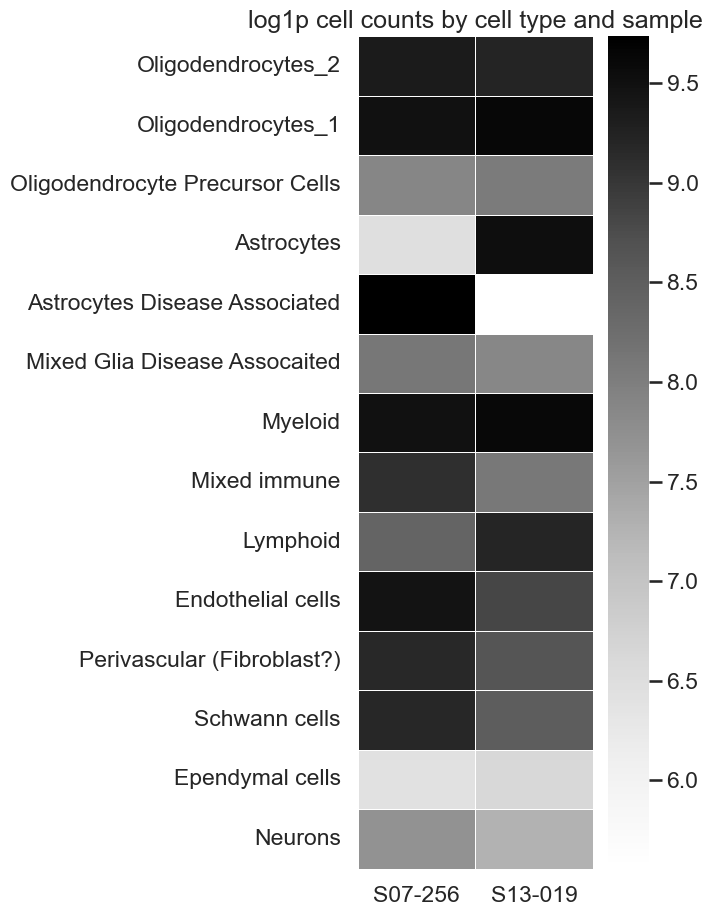

In [9]:
if isinstance(adata.obs[CELLTYPE_COLUMN].dtype, pd.CategoricalDtype):
    observed_celltypes = [str(category) for category in adata.obs[CELLTYPE_COLUMN].cat.categories]
else:
    observed_celltypes = adata.obs[CELLTYPE_COLUMN].astype(str).value_counts().index.tolist()
CELLTYPE_ORDER = ordered_labels(observed_celltypes, PREFERRED_CELLTYPE_ORDER)

if isinstance(adata.obs[SAMPLE_COLUMN].dtype, pd.CategoricalDtype):
    SAMPLE_ORDER = [str(category) for category in adata.obs[SAMPLE_COLUMN].cat.categories]
else:
    SAMPLE_ORDER = sorted(map(str, adata.obs[SAMPLE_COLUMN].dropna().unique()))

celltype_counts = (
    adata.obs[CELLTYPE_COLUMN]
    .astype(str)
    .value_counts()
    .rename("n_cells")
    .reindex(CELLTYPE_ORDER)
)
sample_counts = (
    adata.obs[SAMPLE_COLUMN]
    .astype(str)
    .value_counts()
    .rename("n_cells")
    .reindex(SAMPLE_ORDER)
)
composition = reorder_matrix(
    pd.crosstab(adata.obs[CELLTYPE_COLUMN].astype(str), adata.obs[SAMPLE_COLUMN].astype(str)),
    CELLTYPE_ORDER,
    SAMPLE_ORDER,
)

display(celltype_counts.to_frame())
display(sample_counts.to_frame())
display(composition)

save_table(celltype_counts.to_frame(), RESULTS_DIR / "celltype_counts.csv")
save_table(sample_counts.to_frame(), RESULTS_DIR / "sample_counts.csv")
save_table(composition, RESULTS_DIR / "celltype_by_sample_counts.csv")

plot_heatmap(np.log1p(composition), "log1p cell counts by cell type and sample", cmap="Greys")
#save_current_figure(FIGURES_DIR / "celltype_by_sample_counts.png")


## Major Cell-Type Connexin Signatures

These cells summarize average expression and the fraction of expressing cells for the three connexins across the main `leiden_0.5_names` labels.


,n_cells
leiden_0.5_names,
Oligodendrocytes_2,21571
Oligodendrocytes_1,28160
Oligodendrocyte Precursor Cells,5780
Astrocytes,14512
Astrocytes Disease Associated,17165
Mixed Glia Disease Assocaited,5946
Myeloid,28115
Mixed immune,12167
Lymphoid,14399


,GJC2,GJB1,GJA1
leiden_0.5_names,,,
Oligodendrocytes_2,0.048,0.023,0.018
Oligodendrocytes_1,0.022,0.013,0.051
Oligodendrocyte Precursor Cells,0.002,0.001,0.034
Astrocytes,0.001,0.001,0.588
Astrocytes Disease Associated,0.001,0.000,0.331
Mixed Glia Disease Assocaited,0.000,0.000,0.053
Myeloid,0.001,0.001,0.046
Mixed immune,0.002,0.001,0.053
Lymphoid,0.001,0.000,0.018


,GJC2,GJB1,GJA1
leiden_0.5_names,,,
Oligodendrocytes_2,30.8,18.1,11.6
Oligodendrocytes_1,9.8,6.3,18.6
Oligodendrocyte Precursor Cells,1.1,0.6,15.0
Astrocytes,1.3,0.7,94.7
Astrocytes Disease Associated,0.8,0.3,77.6
Mixed Glia Disease Assocaited,0.3,0.2,26.3
Myeloid,0.7,0.5,19.3
Mixed immune,0.6,0.3,13.8
Lymphoid,0.3,0.2,8.7


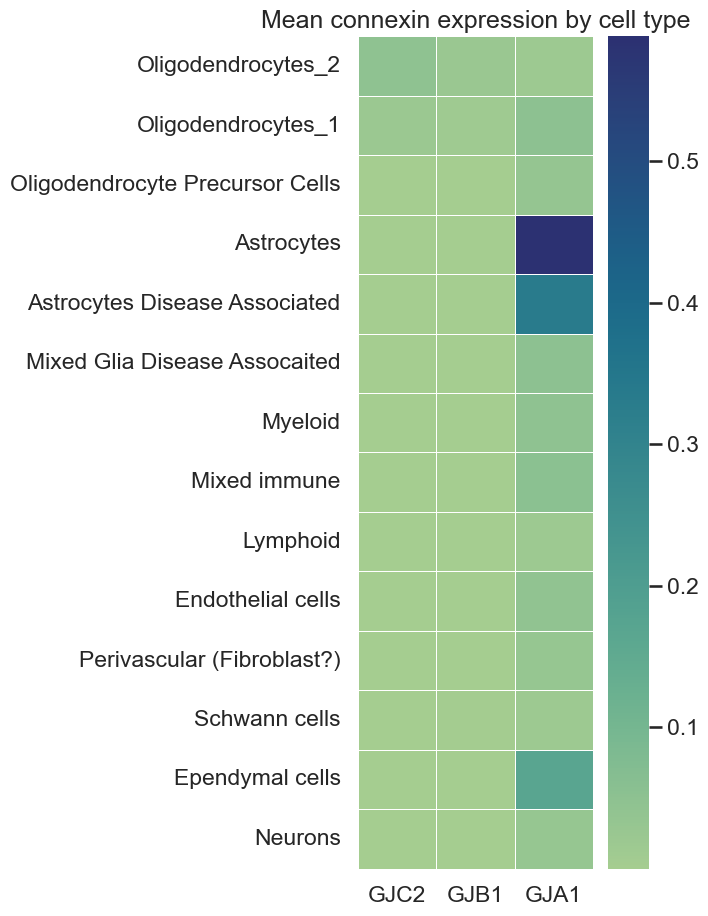

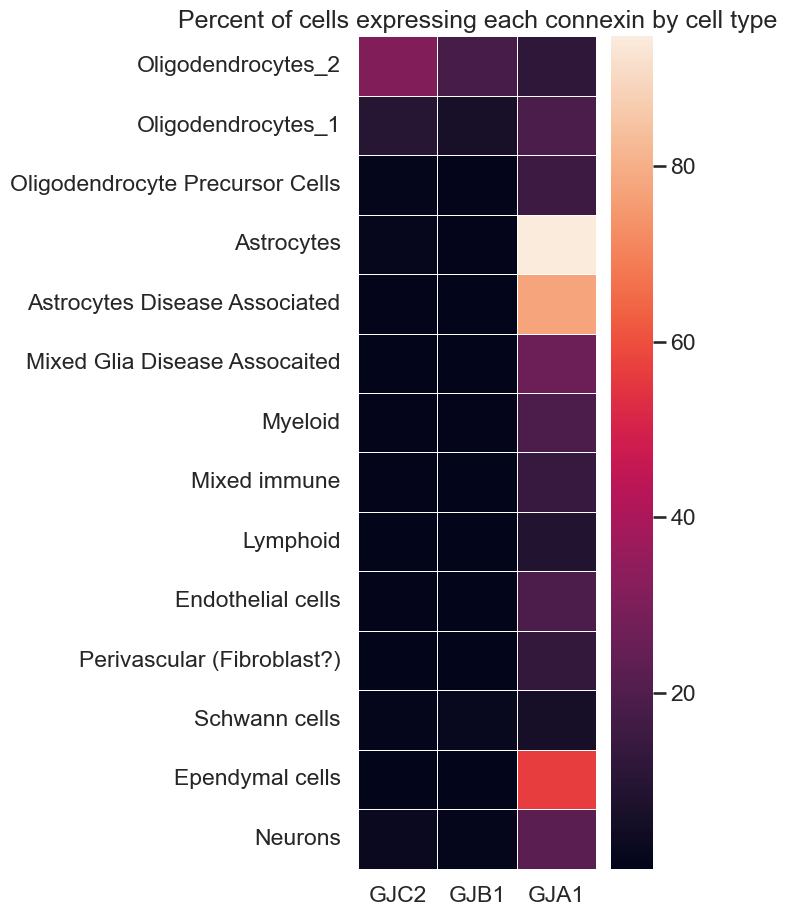

In [10]:
if not present_genes:
    print("None of the target genes are present in this dataset export.")
else:
    celltype_stats = grouped_gene_expression_stats(adata, groupby=CELLTYPE_COLUMN, genes=TARGET_GENES)
    celltype_n = reorder_matrix(celltype_stats["n_cells"], row_order=CELLTYPE_ORDER)
    celltype_mean = reorder_matrix(celltype_stats["mean_expression"], row_order=CELLTYPE_ORDER)
    celltype_pct = reorder_matrix(celltype_stats["pct_expressing"], row_order=CELLTYPE_ORDER)

    display(celltype_n)
    display(celltype_mean.round(3))
    display(celltype_pct.round(1))

    save_table(celltype_n, RESULTS_DIR / "connexin_cell_counts_by_celltype.csv")
    save_table(celltype_mean, RESULTS_DIR / "connexin_mean_by_celltype.csv")
    save_table(celltype_pct, RESULTS_DIR / "connexin_pct_expressing_by_celltype.csv")

    plot_heatmap(celltype_mean, "Mean connexin expression by cell type", cmap="crest")
    #save_current_figure(FIGURES_DIR / "connexin_mean_by_celltype.png")

    plot_heatmap(celltype_pct, "Percent of cells expressing each connexin by cell type", cmap="rocket")
    #save_current_figure(FIGURES_DIR / "connexin_pct_expressing_by_celltype.png")


## Sample-Specific Glial Comparison

To get closer to the panglial question, the next cell narrows to glial labels and compares each sample directly within those categories.


sample_id,S07-256,S13-019
leiden_0.5_names,,
Oligodendrocytes_2,11543,10028
Oligodendrocytes_1,13022,15138
Oligodendrocyte Precursor Cells,2644,3136
Astrocytes,654,13858
Astrocytes Disease Associated,16907,258
Mixed Glia Disease Assocaited,3335,2611


n_cells  GJC2_mean  GJB1_mean  \
leiden_0.5_names                sample_id                                  
Astrocytes                      S07-256        654      0.001      0.000   
                                S13-019      13858      0.001      0.001   
Astrocytes Disease Associated   S07-256      16907      0.001      0.000   
                                S13-019        258      0.001      0.001   
Mixed Glia Disease Assocaited   S07-256       3335      0.000      0.000   
                                S13-019       2611      0.000      0.000   
Oligodendrocyte Precursor Cells S07-256       2644      0.002      0.000   
                                S13-019       3136      0.002      0.001   
Oligodendrocytes_1              S07-256      13022      0.018      0.008   
                                S13-019      15138      0.025      0.017   
Oligodendrocytes_2              S07-256      11543      0.043      0.017   
                                S13-019      10028      0.053      0.030   

                                           GJA1_mean  GJC2_pct  GJB1_pct  \
leiden_0.5_names                sample_id                                  
Astrocytes                      S07-256        0.436     0.459     0.000   
                                S13-019        0.596     1.328     0.779   
Astrocytes Disease Associated   S07-256        0.331     0.751     0.278   
                                S13-019        0.350     1.163     0.775   
Mixed Glia Disease Assocaited   S07-256        0.032     0.150     0.210   
                                S13-019        0.078     0.421     0.230   
Oligodendrocyte Precursor Cells S07-256        0.019     0.794     0.340   
                                S13-019        0.047     1.403     0.829   
Oligodendrocytes_1              S07-256        0.030     6.128     2.757   
                                S13-019        0.069    12.888     9.328   
Oligodendrocytes_2              S07-256        0.011    26.484    13.082   
                                S13-019        0.026    35.670    23.823   

                                           GJA1_pct  
leiden_0.5_names                sample_id            
Astrocytes                      S07-256      77.523  
                                S13-019      95.512  
Astrocytes Disease Associated   S07-256      77.542  
                                S13-019      78.295  
Mixed Glia Disease Assocaited   S07-256      17.481  
                                S13-019      37.457  
Oligodendrocyte Precursor Cells S07-256       7.716  
                                S13-019      21.142  
Oligodendrocytes_1              S07-256       9.937  
                                S13-019      26.120  
Oligodendrocytes_2              S07-256       6.558  
                                S13-019      17.431

,GJC2_S13-019_minus_S07-256,GJB1_S13-019_minus_S07-256,GJA1_S13-019_minus_S07-256
Oligodendrocytes_2,0.011,0.013,0.016
Oligodendrocytes_1,0.007,0.009,0.039
Oligodendrocyte Precursor Cells,0.000,0.001,0.028
Astrocytes,0.001,0.001,0.159
Astrocytes Disease Associated,-0.000,0.001,0.020
Mixed Glia Disease Assocaited,0.000,-0.000,0.046


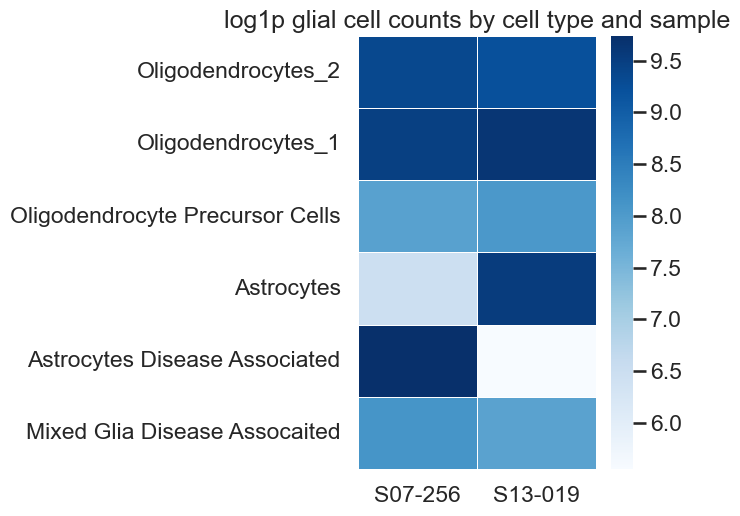

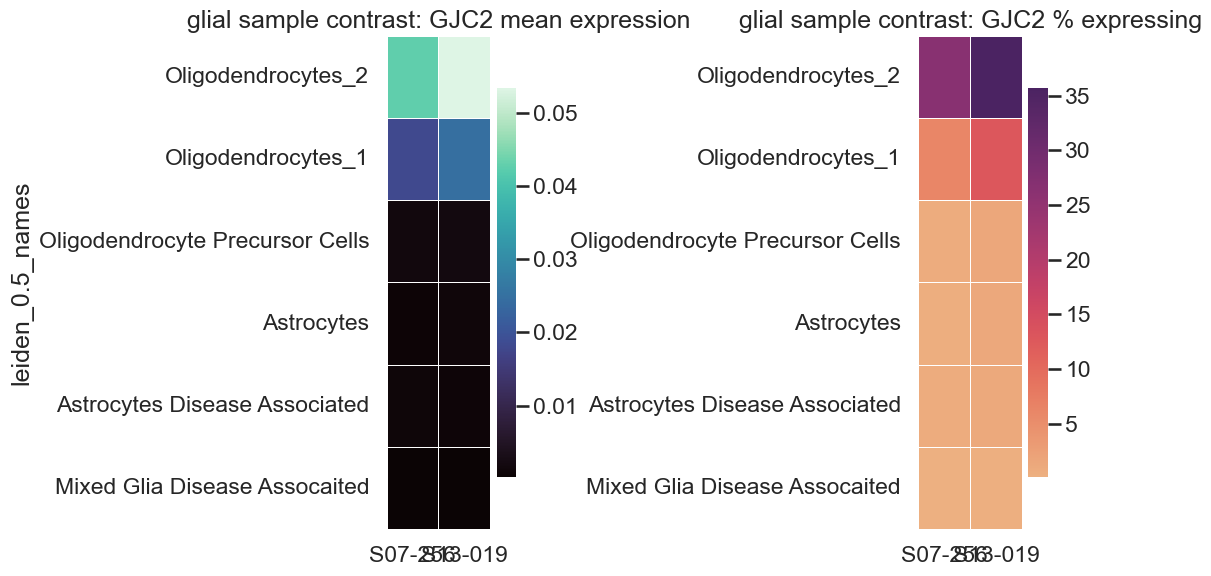

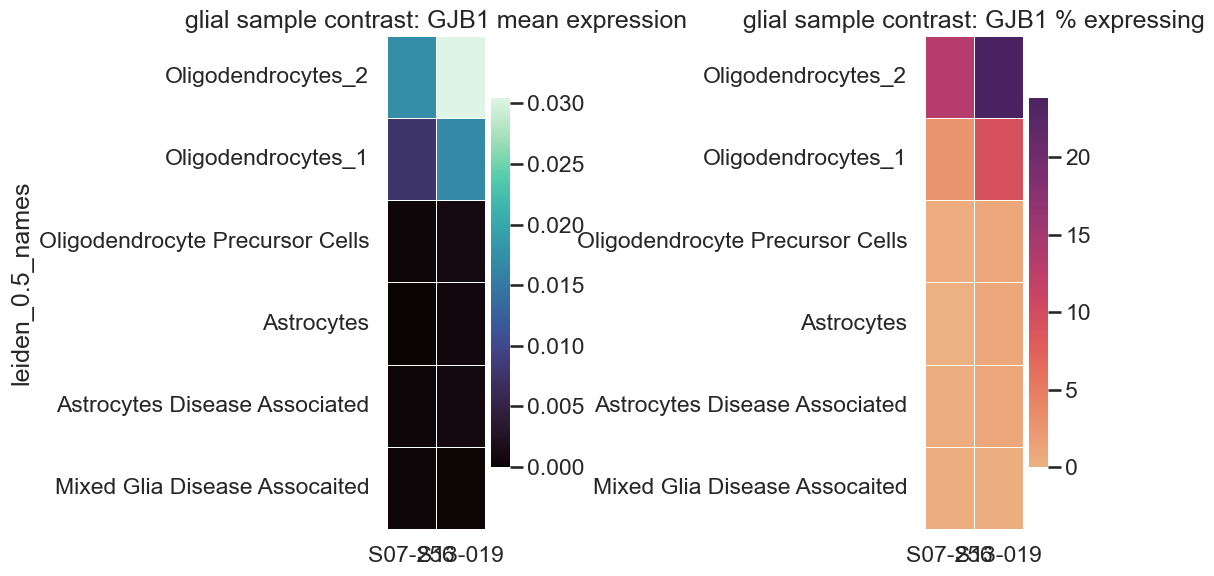

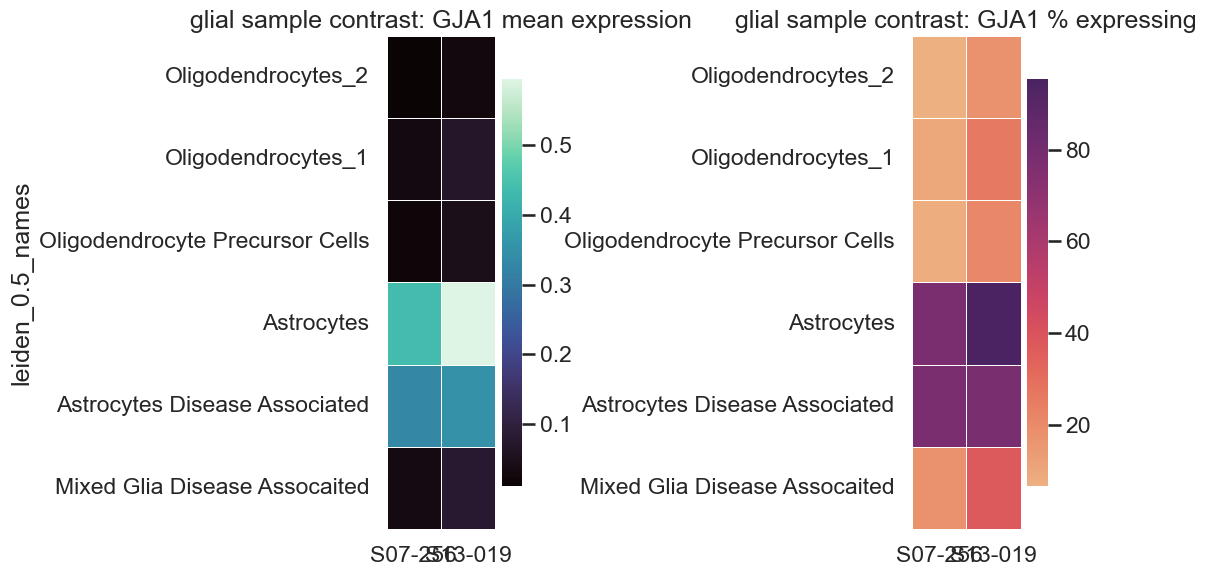

In [11]:
glial_labels = [label for label in GLIAL_PREFERRED_ORDER if label in CELLTYPE_ORDER]
extra_glial_labels = [
    label
    for label in CELLTYPE_ORDER
    if label not in glial_labels and any(keyword in label.lower() for keyword in GLIAL_KEYWORDS)
]
glial_labels = glial_labels + extra_glial_labels

if not glial_labels:
    print("No glial labels were detected in the chosen cell-type column.")
elif not present_genes:
    print("None of the target genes are present in this dataset export.")
else:
    adata_glia = adata[adata.obs[CELLTYPE_COLUMN].astype(str).isin(glial_labels)]
    glial_counts = reorder_matrix(
        pd.crosstab(adata_glia.obs[CELLTYPE_COLUMN].astype(str), adata_glia.obs[SAMPLE_COLUMN].astype(str)),
        glial_labels,
        SAMPLE_ORDER,
    )
    display(glial_counts)
    save_table(glial_counts, RESULTS_DIR / "glial_celltype_by_sample_counts.csv")

    plot_heatmap(np.log1p(glial_counts), "log1p glial cell counts by cell type and sample", cmap="Blues")
    #save_current_figure(FIGURES_DIR / "glial_celltype_by_sample_counts.png")

    glial_stats = two_way_expression_stats(adata_glia, TARGET_GENES, CELLTYPE_COLUMN, SAMPLE_COLUMN)
    glial_mean = glial_stats["mean_expression"]
    glial_pct = glial_stats["pct_expressing"]
    glial_summary = glial_stats["n_cells"].join(glial_mean.add_suffix("_mean")).join(glial_pct.add_suffix("_pct"))
    display(glial_summary.round(3))
    save_table(glial_summary, RESULTS_DIR / "glial_connexin_stats_by_celltype_and_sample.csv")

    for gene in present_genes:
        plot_gene_two_way_heatmaps(
            glial_mean,
            glial_pct,
            gene=gene,
            row_col=CELLTYPE_COLUMN,
            col_col=SAMPLE_COLUMN,
            row_order=glial_labels,
            col_order=SAMPLE_ORDER,
            title_prefix="glial sample contrast",
            mean_cmap="mako",
            pct_cmap="flare",
        )
        #save_current_figure(FIGURES_DIR / f"{gene.lower()}_glial_sample_contrast.png")

    if len(SAMPLE_ORDER) == 2:
        sample_diff = pd.DataFrame(index=glial_labels)
        left_sample, right_sample = SAMPLE_ORDER
        for gene in present_genes:
            mean_matrix = reorder_matrix(glial_mean[[gene]].unstack(SAMPLE_COLUMN)[gene], glial_labels, SAMPLE_ORDER)
            sample_diff[f"{gene}_{right_sample}_minus_{left_sample}"] = mean_matrix[right_sample] - mean_matrix[left_sample]
        display(sample_diff.round(3))
        save_table(sample_diff, RESULTS_DIR / "glial_connexin_sample_differences.csv")


## Next Step

If you later add a spinal-cord dataset with lesion-state or timepoint metadata, the same plotting pattern can be extended to a true progression axis. In the current atlas, the informative comparison is sample-to-sample within the glial labels.
